In [2]:
#Daily Challenge:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
# Project Tasks
# 1. Data Loading and Exploration:

#     Utilize Pandas to load the dataset and explore its initial structure.
df_raw = pd.read_csv('train.csv')
df = df_raw.copy()
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
df.shape

(2000, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [5]:
#There are several columns that could be converted to boolean if that is helpful, though 0/1 should be fine too.

In [6]:
# # # Summarize features, target variable, and their respective data types.
# # Features with explanation & data type in parentheses
# battery_power - Total energy a battery can store in one time measured in mAh (int64)
# blue - Has bluetooth or not (int64 but data is boolean: 1 or 0)
# clock_speed - Speed at which microprocessor executes instructions (float64)
# dual_sim - Has dual sim support or not (int64 but data is boolean: 1 or 0)
# fc - Front Camera mega pixels (int64)
# four_g - Has 4G or not (int64 but data is boolean: 1 or 0)
# int_memory - Internal Memory in Gigabytes (int64)
# m_dep - Mobile Depth in cm (float64)
# mobile_wt - Weight of mobile phone (int64)
# n_cores - Number of cores of processor (int64)
# pc - Primary Camera mega pixels (int64)
# px_height - Pixel Resolution Height (int64)
# px_width - Pixel Resolution Width (int64)
# ram - Random Access Memory in Megabytes (int64)
# sc_h - Screen Height of mobile in cm (int64)
# sc_w - Screen Width of mobile in cm (int64)
# talk_time - Longest time that a single battery charge will last when you are talking on a call (int64)
# three_g - Has 3G or not (int64 but data is boolean: 1 or 0)
# touch_screen - Has touch screen or not (int64 but data is boolean: 1 or 0)
# wifi - Has wifi or not (int64 but data is boolean: 1 or 0)

#Target Variable:
# price_range - This is the target variable with value of:
#     0 (low cost)
#     1 (medium cost)
#     2 (high cost)
#     3 (very high cost)
# (int64)

In [7]:
# Conduct basic descriptive statistics for an overview of the dataset.
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [8]:
# 2. Data Cleaning and Preprocessing:

#     Address missing or null values.

#We've seen with df.info() that there are no nulls. Confirming again:
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [9]:
#Transform categorical data into numerical format using suitable methods.
## All categorical data is already in numerical format.

# 3. Statistical Analysis with NumPy and SciPy:

#     Execute detailed statistical analysis on each feature, including:
#         Calculation of central tendency measures (mean, median, mode).
#         Analysis of variability (range, variance, standard deviation).
#         Evaluation of distribution shapes through skewness and kurtosis.


def get_full_stats_table(df):
    num_df = df.select_dtypes(include=['number'])
    
    def extract_stats(col):
        # 1. Standard SciPy describe
        res = stats.describe(col, nan_policy='omit')
        
        # 2. Extract specific values for calculations
        c_min, c_max = res.minmax
        
        # 3. Handle Mode (Note: Mode returns an object with .mode and .count)
        # We take the first value [0] in case there are multiple modes
        m_res = stats.mode(col, keepdims=True, nan_policy='omit')
        
        return pd.Series({
            'Count': int(res.nobs),
            'Min': c_min,
            'Max': c_max,
            'Range': c_max - c_min,
            'Mean': res.mean,
            'Median': np.nanmedian(col),
            'Mode': m_res.mode[0],
            'Std_Dev': np.sqrt(res.variance), # Or np.nanstd(col, ddof=1)
            'Variance': res.variance,
            'Skewness': res.skewness,
            'Kurtosis': res.kurtosis
        })
    
    return num_df.apply(extract_stats).T

# Apply to dataframe
full_report = get_full_stats_table(df)
print(full_report)

                Count    Min     Max   Range        Mean  Median    Mode  \
battery_power  2000.0  501.0  1998.0  1497.0  1238.51850  1226.0   618.0   
blue           2000.0    0.0     1.0     1.0     0.49500     0.0     0.0   
clock_speed    2000.0    0.5     3.0     2.5     1.52225     1.5     0.5   
dual_sim       2000.0    0.0     1.0     1.0     0.50950     1.0     1.0   
fc             2000.0    0.0    19.0    19.0     4.30950     3.0     0.0   
four_g         2000.0    0.0     1.0     1.0     0.52150     1.0     1.0   
int_memory     2000.0    2.0    64.0    62.0    32.04650    32.0    27.0   
m_dep          2000.0    0.1     1.0     0.9     0.50175     0.5     0.1   
mobile_wt      2000.0   80.0   200.0   120.0   140.24900   141.0   182.0   
n_cores        2000.0    1.0     8.0     7.0     4.52050     4.0     4.0   
pc             2000.0    0.0    20.0    20.0     9.91650    10.0    10.0   
px_height      2000.0    0.0  1960.0  1960.0   645.10800   564.0   347.0   
px_width    

In [10]:
# # Perform hypothesis testing for statistical significance between groups (e.g., different price ranges).

from scipy.stats import f_oneway

results = []

for col in df.columns:
    if col == 'price_range':
        continue
    
    # Calculate ANOVA
    groups = [df[df['price_range'] == i][col] for i in range(4)]
    f_stat, p_val = f_oneway(*groups)
    
    # Append a dictionary for each feature
    results.append({
        'Column': col,
        'F-Stat': round(f_stat, 4),
        'P-Val': f"{p_val:.4f}",
        'Sig. Diff.': p_val < 0.05
    })

# Convert the entire list of results to a DataFrame
anova_table = pd.DataFrame(results)

# Sort by F-Stat to see the most important features at the top
anova_table = anova_table.sort_values(by='F-Stat', ascending=False)
print("Anova One-Way Test Results:")
print(anova_table)

Anova One-Way Test Results:
           Column     F-Stat   P-Val  Sig. Diff.
13            ram  3520.1108  0.0000        True
0   battery_power    31.5982  0.0000        True
12       px_width    22.6209  0.0000        True
11      px_height    19.4848  0.0000        True
8       mobile_wt     3.5943  0.0131        True
6      int_memory     2.9230  0.0328        True
9         n_cores     2.6254  0.0489        True
14           sc_h     2.2260  0.0832       False
15           sc_w     1.6710  0.1712       False
16      talk_time     1.6288  0.1807       False
7           m_dep     1.5007  0.2125       False
18   touch_screen     1.2933  0.2750       False
5          four_g     1.0595  0.3652       False
10             pc     0.8254  0.4797       False
4              fc     0.7722  0.5095       False
2     clock_speed     0.4937  0.6867       False
1            blue     0.4768  0.6985       False
17        three_g     0.4573  0.7122       False
3        dual_sim     0.4282  0.7328     

In [11]:
# Summary: There is a significant difference among groups for ram, battery_power, px_width, px_height, mobile_wt, int_memory, and n_cores.



# Investigate feature-target correlations using SciPy.


# 1. Standard Correlation Matrix (Treating price_range as ordinal)
# This gives a quick linear snapshot
corr_matrix = df.corr()
price_correlations = corr_matrix['price_range'].sort_values(ascending=False)
price_correlations


price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

In [13]:
# 2. ANOVA F-Test (The more robust "Feature Importance" check)
from sklearn.feature_selection import f_classif

# Separate features and target
X = df.drop('price_range', axis=1)
y = df['price_range']

# Calculate F-values and P-values
f_values, p_values = f_classif(X, y)

# Create a results table
anova_results = pd.DataFrame({
    'Feature': X.columns,
    'F_Score': f_values,
    'P_Value': p_values
}).sort_values(by='F_Score', ascending=False)
print('ANOVA F-Test Results:')
print(anova_results.head(10))

ANOVA F-Test Results:
          Feature      F_Score       P_Value
13            ram  3520.110824  0.000000e+00
0   battery_power    31.598158  5.948688e-20
12       px_width    22.620882  2.116911e-14
11      px_height    19.484842  1.886085e-12
8       mobile_wt     3.594318  1.311739e-02
6      int_memory     2.922996  3.277694e-02
9         n_cores     2.625415  4.893585e-02
14           sc_h     2.225984  8.324991e-02
15           sc_w     1.671000  1.712146e-01
16      talk_time     1.628811  1.806686e-01


In [14]:
# Conclusion from both analyses: ram is the only feature that appears to have a statistically significant importance to price range, and is the only feature that has a strong correlation with price range.


# Apply advanced SciPy statistical functions for deeper insights.
#Kruskal-Wallis H-Test (Non-parametric ANOVA) (The Kruskal-Wallis test is the safer, "non-parametric" alternative to ANOVA that doesn't assume a bell-curve distribution.)
from scipy.stats import kruskal


results = []

for col in df.columns:
    if col == 'price_range':
        continue
    
    # Calculate Kruskal
    groups = [df[df['price_range'] == i][col] for i in range(4)]
    h_stat, p_val = kruskal(*groups)
    
    # Append a dictionary for each feature
    results.append({
        'Column': col,
        'H-Stat': round(h_stat, 4),
        'P-Val': f"{p_val:.4f}",
        'Big Differentiator': p_val < 0.05
    })

# Convert the entire list of results to a DataFrame
kruskal_table = pd.DataFrame(results)

# Sort by H-Stat to see the most important features at the top
kruskal_table = kruskal_table.sort_values(by='H-Stat', ascending=False)
print('Kruskal Test Results')
print(kruskal_table)

Kruskal Test Results
           Column     H-Stat   P-Val  Big Differentiator
13            ram  1681.4965  0.0000                True
0   battery_power    90.1357  0.0000                True
12       px_width    65.2308  0.0000                True
11      px_height    47.1814  0.0000                True
8       mobile_wt    10.8193  0.0127                True
6      int_memory     8.7685  0.0325                True
9         n_cores     7.8784  0.0486                True
14           sc_h     6.6880  0.0825               False
16      talk_time     4.8951  0.1796               False
7           m_dep     4.5730  0.2059               False
18   touch_screen     3.8782  0.2749               False
5          four_g     3.1783  0.3649               False
15           sc_w     2.6369  0.4511               False
10             pc     2.3671  0.4998               False
4              fc     2.0775  0.5565               False
1            blue     1.4314  0.6982               False
17        

In [ ]:
# Conclusion: This test shows several features as big differentiators for price range:
# ram, battery_power, px_width, px_height, mobile_wt, int_memory, and n_cores.


#  Levene’s Test for Homogeneity of Variance:
# This test examines the following: Does the "spread" (volatility) of a feature change as phones get more expensive? For example: Do "Very High Cost" phones have a wider variety of internal_memory than "Low Cost" phones?
from scipy.stats import levene

results = []

for col in df.columns:
    if col == 'price_range':
        continue
    
    # Calculate Levene
    groups = [df[df['price_range'] == i][col] for i in range(4)]
    stat, p_levene = levene(*groups)
    
    # Append a dictionary for each feature
    results.append({
        'Column': col,
        'Stat': round(stat, 4),
        'P-Value': f"{p_levene:.4f}",
        'Consistency varies by price tier': p_levene < 0.05
    })

# Convert the entire list of results to a DataFrame
levene_table = pd.DataFrame(results)

# Sort by H-Stat to see the most important features at the top
levene_table = levene_table.sort_values(by='Stat', ascending=False)
print('Levene Test Results')
print(levene_table)

Levene Test Results
           Column     Stat P-Value  Consistency varies by price tier
13            ram  16.3302  0.0000                              True
11      px_height  12.8832  0.0000                              True
0   battery_power   5.6085  0.0008                              True
15           sc_w   5.5154  0.0009                              True
2     clock_speed   2.7910  0.0392                              True
8       mobile_wt   2.0636  0.1031                             False
4              fc   0.7614  0.5157                             False
12       px_width   0.7586  0.5173                             False
5          four_g   0.6910  0.5575                             False
6      int_memory   0.5429  0.6529                             False
3        dual_sim   0.5001  0.6822                             False
17        three_g   0.4573  0.7122                             False
16      talk_time   0.4321  0.7301                             False
14           s

In [ ]:
# Conclusion: The spread of several features varies by price tier: ram, px_height, battery_power, sc_w, and clock_speed.


# Spearman Rank Correlation (Non-linear Relationship).
# Unlike Pearson correlation, which looks for linear relationships, Spearman looks for monotonic relationships. Since the target variable price_range is ordinal (ordered categories 0, 1, 2, 3), Spearman is the mathematically superior choice because it correlates the ranks of the variables rather than their raw values.

from scipy.stats import spearmanr

# 1. Create a results list
spearman_results = []

# 2. Iterate through all columns except the target
for col in df.columns:
    if col == 'price_range':
        continue
    
    # Calculate Spearman Correlation
    coeff, p_value = spearmanr(df[col], df['price_range'])
    
    spearman_results.append({
        'Feature': col,
        'Correlation': coeff,
        'P-Value': round(p_value,4)
    })

# 3. Convert to DataFrame and sort by the strength of correlation
spearman_df = pd.DataFrame(spearman_results).sort_values(by='Correlation', ascending=False)

print(spearman_df)

          Feature  Correlation  P-Value
13            ram     0.917080   0.0000
0   battery_power     0.199991   0.0000
12       px_width     0.165134   0.0000
11      px_height     0.131884   0.0000
6      int_memory     0.044278   0.0477
10             pc     0.032824   0.1423
15           sc_w     0.024776   0.2681
4              fc     0.024167   0.2800
14           sc_h     0.023727   0.2889
17        three_g     0.023611   0.2912
16      talk_time     0.022138   0.3224
1            blue     0.020573   0.3578
19           wifi     0.018785   0.4011
3        dual_sim     0.017444   0.4356
5          four_g     0.014772   0.5091
9         n_cores     0.004651   0.8353
7           m_dep    -0.000322   0.9885
2     clock_speed    -0.005436   0.8080
8       mobile_wt    -0.030214   0.1768
18   touch_screen    -0.030411   0.1740


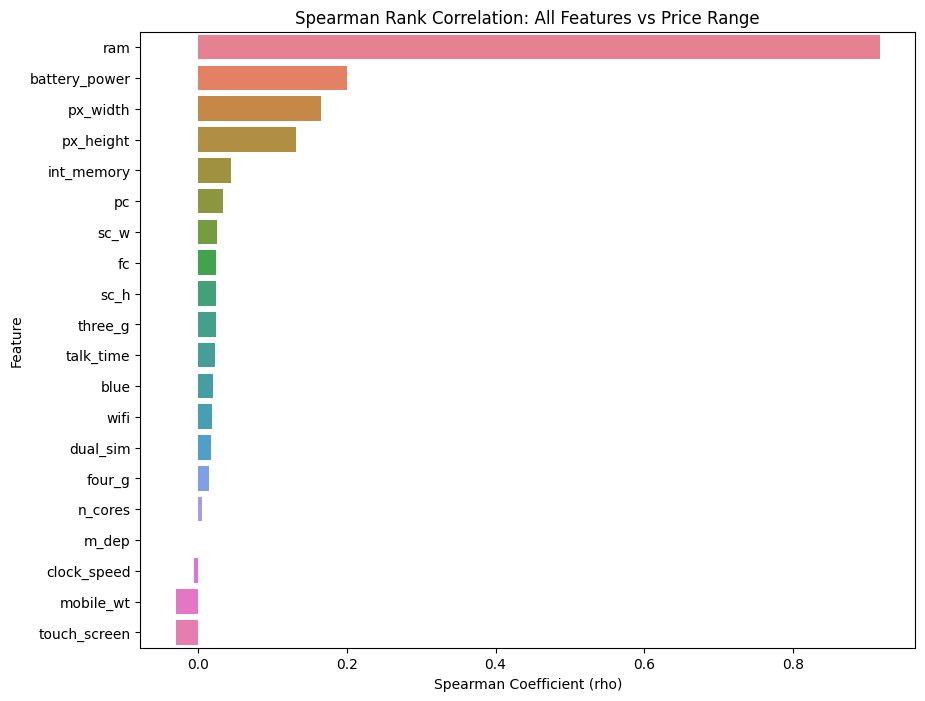

In [ ]:
# Conclusion: Several features have statistically significant correlations with price range, but only ram has a strong degree of correlation. We can see this in the following visualization as well:

plt.figure(figsize=(10, 8))
sns.barplot(x='Correlation', y='Feature', data=spearman_df, hue='Feature', legend=False)
plt.title('Spearman Rank Correlation: All Features vs Price Range')
plt.xlabel('Spearman Coefficient (rho)')
plt.show()

Pair Plot: Histograms of Feature Distribution and Scatter Charts of Relationships between Features


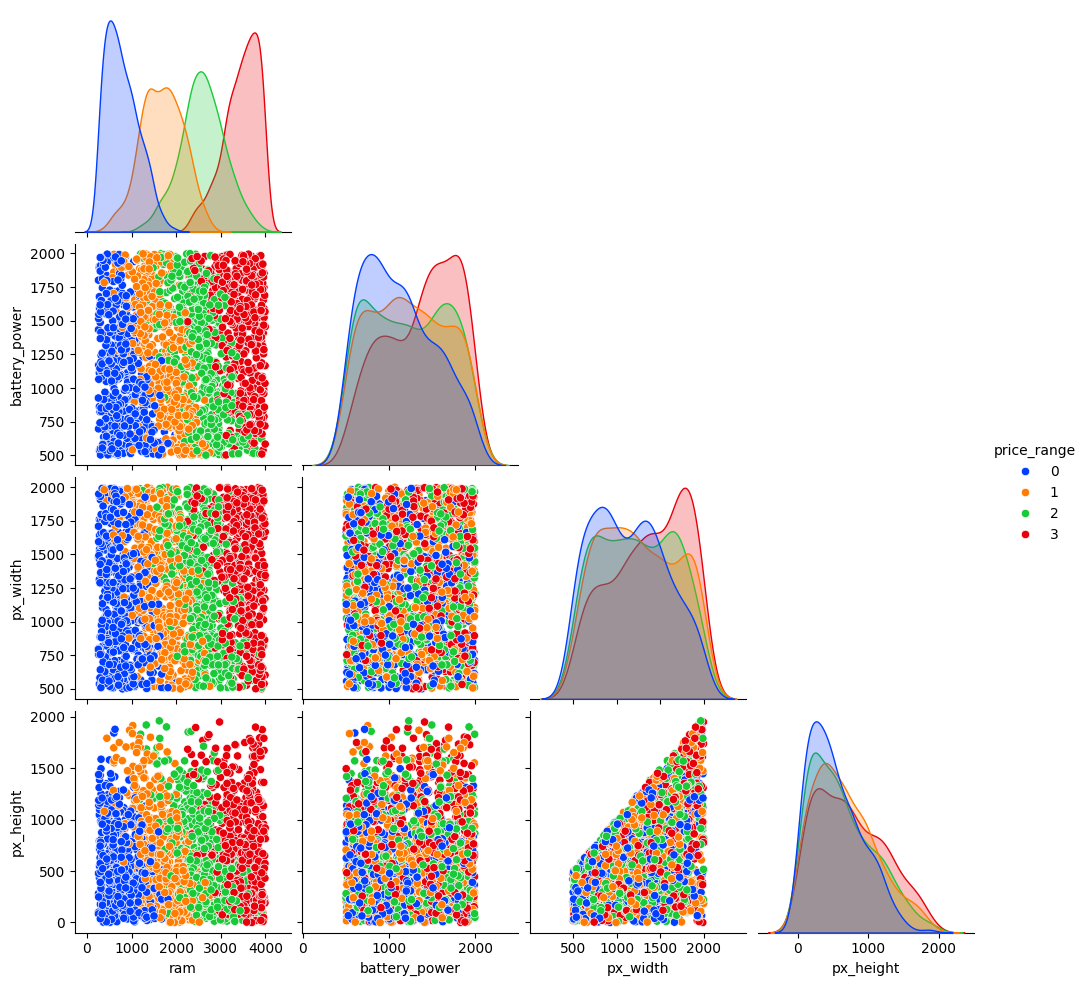

In [ ]:
# Conclusion:
########FINISH WORK HERE.



# 4. Data Visualization with Matplotlib:

#     Produce histograms, scatter plots, and box plots for data distribution and relationship insights.

# Selecting the top 4 features from our earlier Spearman analysis
top_features = ['ram', 'battery_power', 'px_width', 'px_height', 'price_range']

print('Pair Plot: Histograms of Feature Distribution and Scatter Charts of Relationships between Features')
sns.pairplot(df[top_features], hue='price_range', palette='bright', corner=True)

plt.show()

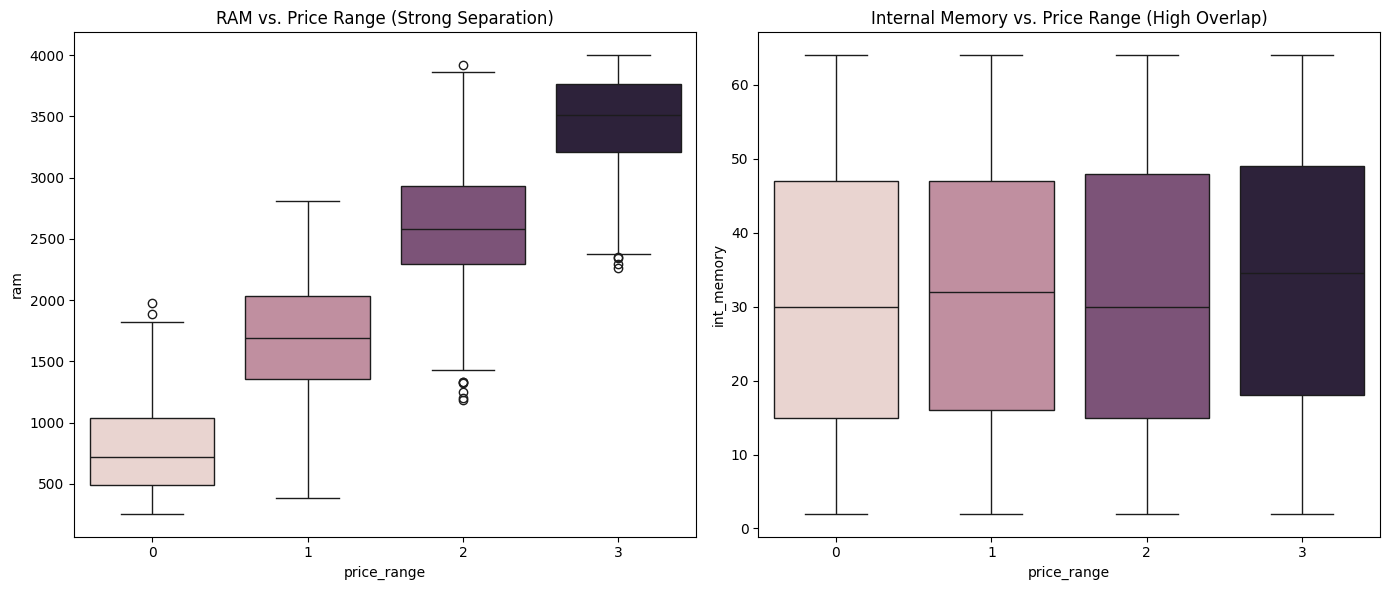

In [ ]:
plt.figure(figsize=(14, 6))

# Boxplot for RAM vs Price Range
plt.subplot(1, 2, 1)
sns.boxplot(x='price_range', y='ram', data=df, hue='price_range',legend=False)
plt.title('RAM vs. Price Range (Strong Separation)')

# Boxplot for Internal Memory vs Price Range
plt.subplot(1, 2, 2)
sns.boxplot(x='price_range', y='int_memory', data=df, hue='price_range',legend=False)
plt.title('Internal Memory vs. Price Range (High Overlap)')

plt.tight_layout()
plt.show()

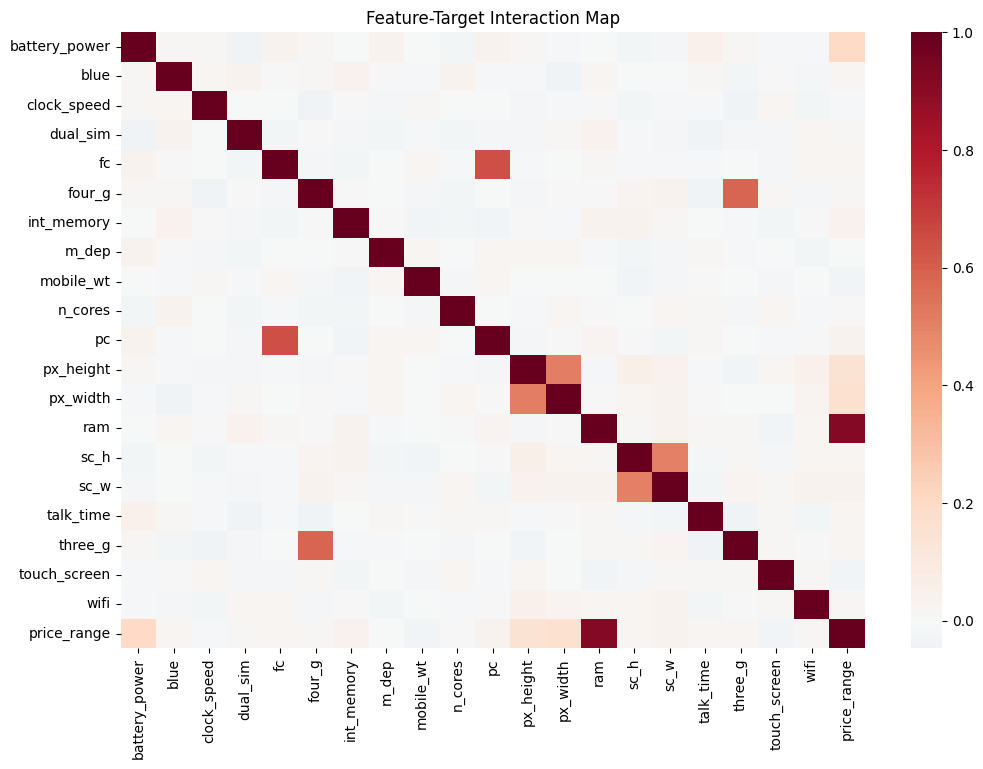

In [ ]:
# We notice that ram has almost no overlap between categories, while int_memory has massive overlap. This tells you RAM is a "hard" requirement for a higher price tier, while internal memory is just a "nice-to-have."

#Employ heatmaps for correlation visualization.
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='RdBu_r', center=0)
plt.title('Feature-Target Interaction Map')
plt.show()

In [ ]:
# "Derive conclusions from statistical tests and visualizations.
# Identify key determinants in mobile price classification.
# Highlight any unexpected or significant findings."


#